In [41]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (Layer, Conv1D, GlobalAveragePooling1D,
                                   Reshape, Flatten, Dense, LeakyReLU,
                                   Conv1DTranspose, UpSampling1D, Input,
                                   MaxPooling1D, BatchNormalization)
from tensorflow.keras import Model
from tensorflow.keras.optimizers import Nadam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
!pip install tensorflow-addons

ERROR: Could not find a version that satisfies the requirement tensorflow-addons (from versions: none)
ERROR: No matching distribution found for tensorflow-addons


In [42]:
tf.random.set_seed(42)
np.random.seed(42)

## Model Defination

##1-D Auto Encoder

In [43]:
# def load_and_preprocess_data():
#     # Load your datasets (replace with your actual file paths)
#     df_control = pd.read_csv("/content/circular_fm_new_pd_vs_swedd_V3 .csv")
#     df_pd = pd.read_csv("/content/fm_new_control_and_pd.csv")

#     # Combine datasets (adjust as needed)
#     df = pd.concat([df_control, df_pd], axis=0)

#     # Extract features and labels
#     X = df.iloc[:, 2:26].values  # Adjust column indices as needed
#     y = df.iloc[:, 26].values    # Adjust column index as needed

#     # Normalize features
#     scaler = StandardScaler()
#     X_normalized = scaler.fit_transform(X)

#     # Split data
#     X_train, X_test, y_train, y_test = train_test_split(
#         X_normalized, y, test_size=0.2, random_state=42, stratify=y)

#     # Reshape for Conv1D
#     X_train = X_train.reshape(-1, X_train.shape[1], 1)
#     X_test = X_test.reshape(-1, X_train.shape[1], 1)

#     return X_train, X_test, y_train, y_test, scaler

In [44]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

def load_and_preprocess_data_kfold(n_splits=5):

    df_control = pd.read_csv("/content/fm_control_and_pd (3).csv")

    # Combine datasets
    df = df_control

    # Extract features and labels
    X = df.iloc[:, 2:26].values  # Adjust indices if needed
    y = df.iloc[:, 26].values

    # Normalize features
    scaler = StandardScaler()
    X_normalized = scaler.fit_transform(X)

    # Reshape for Conv1D
    X_reshaped = X_normalized.reshape(-1, X_normalized.shape[1], 1)

    # Create Stratified K-Folds
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    folds = []
    for train_idx, test_idx in skf.split(X_reshaped, y):
        X_train, X_test = X_reshaped[train_idx], X_reshaped[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        folds.append((X_train, X_test, y_train, y_test))

    return folds, scaler


In [45]:
class DPHO_CRU(Layer):
    def __init__(self, projection_dim=4, epsilon=1e-4, groups=None, **kwargs):
        """
        Dual-Pool Higher-Order Channel Refinement Unit with group-wise processing.

        Args:
            projection_dim: Dimension for row-wise embeddings (default 4)
            epsilon: Small constant for numerical stability
            groups: Number of groups (should equa l input channels)
        """
        super(DPHO_CRU, self).__init__(**kwargs)
        self.projection_dim = projection_dim
        self.epsilon = epsilon
        self.groups = groups

    def build(self, input_shape):
        self.channels = input_shape[-1]  # Number of channels C

        # Validate groups parameter
        if self.groups is None:
            self.groups = self.channels
        if self.groups != self.channels:
            raise ValueError(f"Number of groups ({self.groups}) must equal number of channels ({self.channels})")

        # Row-wise convolution for covariance path (grouped)
        self.row_conv = Conv1D(
            filters=self.projection_dim*self.groups,
            kernel_size=self.channels,
            padding='valid',
            activation='leaky_relu',
            groups=self.groups  # Critical group-wise operation
        )

        # Shared projection layer (applied per-channel)
        self.shared_proj = Dense(
            units=1,
            activation=None,
            use_bias=True
        )

        # Final fusion layer (1x1 conv)
        self.fusion_conv = Conv1D(
            filters=self.channels,
            kernel_size=1,
            padding='same'
        )

        super(DPHO_CRU, self).build(input_shape)

    def compute_normalized_covariance(self, x):
        """Steps 1-3: Centering -> Covariance -> Normalization"""
        # Step 1: Input Centering
        mean = tf.reduce_mean(x, axis=1, keepdims=True)  # [B, 1, C]
        x_centered = x - mean                           # [B, L, C]

        # Step 2: Covariance matrix
        cov = tf.matmul(x_centered, x_centered, transpose_a=True) / \
              tf.cast(tf.shape(x)[1], tf.float32)       # [B, C, C]

        # Step 3: Row-wise normalization
        row_norms = tf.sqrt(tf.reduce_sum(tf.square(cov), axis=-1, keepdims=True)) + self.epsilon
        return cov / row_norms                          # [B, C, C]

    def call(self, inputs):
        B = tf.shape(inputs)[0]
        C = self.channels

        # === Covariance Path ===
        norm_cov = self.compute_normalized_covariance(inputs)  # [B, C, C]

        # Step 4: Grouped row-wise embedding
        # Each channel processed independently due to groups=C
        z = self.row_conv(norm_cov)  # [B, C, projection_dim]

        # Step 5: Shared projection (per-channel)
        alpha_cov = self.shared_proj(z)  # [B, C, 1]
        alpha_cov = tf.transpose(alpha_cov, [0, 2, 1])  # [B, 1, C]
        alpha_cov = tf.sigmoid(alpha_cov)

        # === Average Pooling Path ===
        alpha_avg = tf.reduce_mean(inputs, axis=1, keepdims=True)  # [B, 1, C]
        alpha_avg = tf.sigmoid(alpha_avg)

        # === Concatenate Paths ===
        combined = tf.concat([alpha_avg, alpha_cov], axis=-1)  # [B, 1, 2C]

        # === Final Attention Generation ===
        attention = self.fusion_conv(combined)  # [B, 1, C]
        attention = tf.sigmoid(attention)      # [B, 1, C]

        # === Channel-wise Reweighting ===
        return inputs * attention              # [B, L, C]

    def get_config(self):
        config = super(DPHO_CRU, self).get_config()
        config.update({
            'projection_dim': self.projection_dim,
            'epsilon': self.epsilon,
            'groups': self.groups
        })
        return config

In [46]:
class CRU(Layer):
    def __init__(self, reduction_ratio=4, **kwargs):
        super(CRU, self).__init__(**kwargs)
        self.reduction_ratio = reduction_ratio

    def build(self, input_shape):
        self.channels = input_shape[-1]
        self.reduced_channels = max(1, self.channels // self.reduction_ratio)

        # GAP pathway
        self.gap = GlobalAveragePooling1D()
        self.fc1 = Dense(self.reduced_channels, activation='relu')
        self.fc2 = Dense(self.channels, activation='sigmoid')

        # Covariance pathway
        self.cov_fc1 = Dense(self.reduced_channels, activation='relu')
        self.cov_fc2 = Dense(self.channels, activation='sigmoid')
        self.bn = BatchNormalization()

    def call(self, inputs):
        # GAP pathway
        gap = self.gap(inputs)
        gap = self.fc1(gap)
        gap_weights = self.fc2(gap)

        # Covariance pathway
        B = tf.shape(inputs)[0]
        T = tf.shape(inputs)[1]
        C = tf.shape(inputs)[2]

        mean = tf.reduce_mean(inputs, axis=1, keepdims=True)
        centered = inputs - mean
        cov = tf.matmul(centered, centered, transpose_a=True)
        cov = cov / tf.cast(T - 1, tf.float32)

        cov_flat = tf.reshape(cov, [B, C*C])
        cov_processed = self.cov_fc1(cov_flat)
        cov_weights = self.cov_fc2(cov_processed)
        cov_weights = self.bn(cov_weights)

        combined_weights = tf.sigmoid(gap_weights * cov_weights)
        return inputs * tf.expand_dims(combined_weights, axis=1)

    def get_config(self):
        config = super(CRU, self).get_config()
        config.update({'reduction_ratio': self.reduction_ratio})
        return config

In [47]:
import tensorflow
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import LeakyReLU

# Make sure DPHO_CRU is defined or imported above this
def build_autoencoder(input_shape):
    # Input
    input_layer = Input(shape=input_shape)

    # Encoder
    x = Conv1D(16, 5, padding='same')(input_layer)
    x = BatchNormalization()(x)  # Added batch normalization

    x = LeakyReLU(alpha=0.2)(x)
    x =CRU(groups=16)(x)  # Replaced CRU with DPHO_CRU
    layer1 = x

    x = MaxPooling1D(2)(x)
    layer2 = x

    x = Conv1D(8, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha=0.2)(x)
    x =CRU(groups=8)(x)
    layer3 = x

    bottleneck1 = Conv1D(1, 1, padding='same')(x)
    x = BatchNormalization()(x)
    bottleneck1 = LeakyReLU(alpha=0.2)(bottleneck1)
    bottleneck1 = CRU(groups=1)(bottleneck1)
    layer4 = bottleneck1

    bottleneck2 = Conv1D(1, 1, padding='same')(bottleneck1)
    x = BatchNormalization()(x)
    bottleneck2 = LeakyReLU(alpha=0.2)(bottleneck2)
    bottleneck2 = CRU(groups=1)(bottleneck2)
    layer5 = bottleneck2

    # Decoder
    x = Conv1DTranspose(8, 1, padding='same')(bottleneck2)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = CRU(groups=8)(x)
    layer6 = x

    x = Conv1DTranspose(16, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = CRU(groups=16)(x)
    layer7 = x

    x = UpSampling1D(2)(x)
    layer8 = x

    # Output layers
    reconstruction = Conv1DTranspose(1, 5, padding='same', activation='linear', name='reconstruction')(x)
    layer9 = reconstruction

    classification = Flatten()(bottleneck1)

    classification = Dense(8)(classification)
    classification = BatchNormalization()(classification)

    classification = LeakyReLU(negative_slope=0.2)(classification)  # You can adjust alpha if needed





    classification = Dense(1, activation='sigmoid', name='classification')(classification)

    print(input_layer.shape)
    main_model = Model(
        inputs=input_layer,
        outputs=[reconstruction, classification],
        name="dual_output_autoencoder"
    )

    intermediate_model = Model(
        inputs=input_layer,
        outputs=[layer1, layer2, layer3, layer4, layer5, layer6, layer7, layer8, layer9],
        name="intermediate_layer_model"
    )

    return main_model, intermediate_model

In [48]:
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.metrics import Metric
import tensorflow as tf

class F1Score(Metric):
    def __init__(self, name='f1_score', threshold=0.5, **kwargs):
        super(F1Score, self).__init__(name=name, **kwargs)
        self.threshold = threshold
        self.precision = Precision(thresholds=self.threshold)
        self.recall = Recall(thresholds=self.threshold)

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.cast(y_pred >= self.threshold, tf.float32)
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + tf.keras.backend.epsilon()))

    def reset_states(self):
        self.precision.reset_states()
        self.recall.reset_states()


In [49]:
from sklearn.utils.class_weight import compute_class_weight

def get_class_weights(y):
    classes = np.unique(y)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y)
    return dict(zip(classes, weights))

def get_sample_weights(y, class_weights):
    return np.array([class_weights[cls] for cls in y])


In [50]:
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.optimizers import Nadam
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.metrics import AUC, Precision, Recall
import numpy as np
import matplotlib.pyplot as plt

# Define or import your F1Score here if it's a custom metric
# from your_metrics import F1Score

def get_sample_weights(y, class_weights):
    return np.array([class_weights[int(label)] for label in y])

def train_model(n_splits=5, epochs=52, batch_size=32):
    folds, scaler = load_and_preprocess_data_kfold(n_splits=n_splits)
    all_histories = []

    for i, (X_train, X_test, y_train, y_test) in enumerate(folds):
        print(f"\nTraining on Fold {i + 1}/{n_splits}...")

        main_model, intermediate_model = build_autoencoder(X_train.shape[1:])

        main_model.compile(
            optimizer=Nadam(learning_rate=1e-4),
            loss={
                'reconstruction': 'mse',
                'classification': 'binary_crossentropy'
            },
            loss_weights={
                'reconstruction': 0.1,
                'classification': 1.0
            },
            metrics={
                'reconstruction': ['mse', 'mae'],
                'classification': [
                    'accuracy',
                    AUC(name='auc'),
                    Precision(name='precision'),
                    Recall(name='recall'),
                    F1Score(name='f1_score')  # Make sure F1Score is defined
                ]
            }
        )

        # Compute class and sample weights
        #cw = compute_class_weight(
         #   class_weight='balanced',
          #  classes=np.unique(y_train),
           # y=y_train
        #)
        #class_weights = dict(zip(np.unique(y_train), cw))
        #classification_weights = get_sample_weights(y_train, class_weights).astype(np.float32)

        history = main_model.fit(
            x=X_train,
            y={'reconstruction': X_train, 'classification': y_train},
            validation_data=(X_test, {'reconstruction': X_test, 'classification': y_test}),
            epochs=epochs,
            batch_size=batch_size,
            verbose=1
        )
        all_histories.append(history.history)

    # Average metrics over folds per epoch
    avg_history = {}
    keys = all_histories[0].keys()

    for key in keys:
        values = [fold_hist[key] for fold_hist in all_histories if key in fold_hist]
        values = np.array(values)
        avg_history[key] = np.mean(values, axis=0)

    # --- Plot accuracy, precision, recall, f1 score on one graph ---
    plt.figure(figsize=(10, 6))
    metrics = ['accuracy', 'precision', 'recall', 'f1_score']
    for metric in metrics:
        train_key = f'classification_{metric}'
        val_key = f'val_classification_{metric}'
        if train_key in avg_history:
            plt.plot(avg_history[train_key], label=f'Train {metric.capitalize()}')
        if val_key in avg_history:
            plt.plot(avg_history[val_key], label=f'Val {metric.capitalize()}')
    plt.title('Average Accuracy, Precision, Recall, and F1 Score vs Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --- Plot AUC separately ---
    plt.figure(figsize=(10, 6))
    if 'classification_auc' in avg_history:
        plt.plot(avg_history['classification_auc'], label='Train AUC')
    if 'val_classification_auc' in avg_history:
        plt.plot(avg_history['val_classification_auc'], label='Val AUC')
    plt.title('Average AUC vs Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('AUC')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Print final average metrics
    # Compute and print average metrics (mean ± std) at final epoch
    print("\n=== Average Metrics at Final Epoch (Mean ± Std) ===")
    final_epoch_stats = {}

    for key in keys:
        values = [fold_hist[key][-1] for fold_hist in all_histories if key in fold_hist]
        if values:
            mean_val = np.mean(values)
            std_val = np.std(values)
            final_epoch_stats[key] = (mean_val, std_val)
            print(f"{key}: {mean_val:.4f} ± {std_val:.4f}")


    return main_model, avg_history, scaler, intermediate_model, X_train




In [51]:
# def train_model():
#     # Load and preprocess data
#     X_train, X_test, y_train, y_test, scaler = load_and_preprocess_data_kfold()

#     # Build model
#     main_model, intermediate_model = build_autoencoder(X_train.shape[1:])

#     # Compile the main model
#     main_model.compile(
#         optimizer=Nadam(learning_rate=1e-4),
#         loss={
#             'reconstruction': 'mse',
#             'classification': 'binary_crossentropy'
#         },
#         loss_weights={
#             'reconstruction': 0.4,
#             'classification': 1
#         },
#         metrics={
#             'reconstruction': ['mse', 'mae'],
#             'classification': ['accuracy', 'AUC']
#         }
#     )

#     # Train model
#     print("Starting training...")
#     history = main_model.fit(
#         X_train,
#         {
#             'reconstruction': X_train,
#             'classification': y_train
#         },
#         validation_data=(
#             X_test,
#             {
#                 'reconstruction': X_test,
#                 'classification': y_test
#             }
#         ),
#         epochs=100,
#         batch_size=16,
#         verbose=1
#     )

#     print("Training completed!")
#     return main_model, history, scaler, intermediate_model'''


Starting training...

Training on Fold 1/5...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


(None, 24, 1)
Epoch 1/52
29/29 ━━━━━━━━━━━━━━━━━━━━ 28s 275ms/step - classification_accuracy: 0.4020 - classification_auc: 0.4148 - classification_f1_score: 0.5156 - classification_loss: 0.8926 - classification_precision: 0.8006 - classification_recall: 0.3803 - loss: 1.0823 - reconstruction_loss: 1.8637 - reconstruction_mae: 1.0800 - reconstruction_mse: 1.8653 - val_classification_accuracy: 0.2996 - val_classification_auc: 0.4127 - val_classification_f1_score: 0.3402 - val_classification_loss: 0.7605 - val_classification_precision: 0.8200 - val_classification_recall: 0.2147 - val_loss: 0.8461 - val_reconstruction_loss: 0.9968 - val_reconstruction_mae: 0.7572 - val_reconstruction_mse: 0.9788
Epoch 2/52
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - classification_accuracy: 0.4130 - classification_auc: 0.4300 - classification_f1_score: 0.5254 - classification_loss: 0.8764 - classification_precision: 0.8127 - classification_recall: 0.3882 - loss: 1.0415 - reconstruction_loss: 1.6178 - reconstr

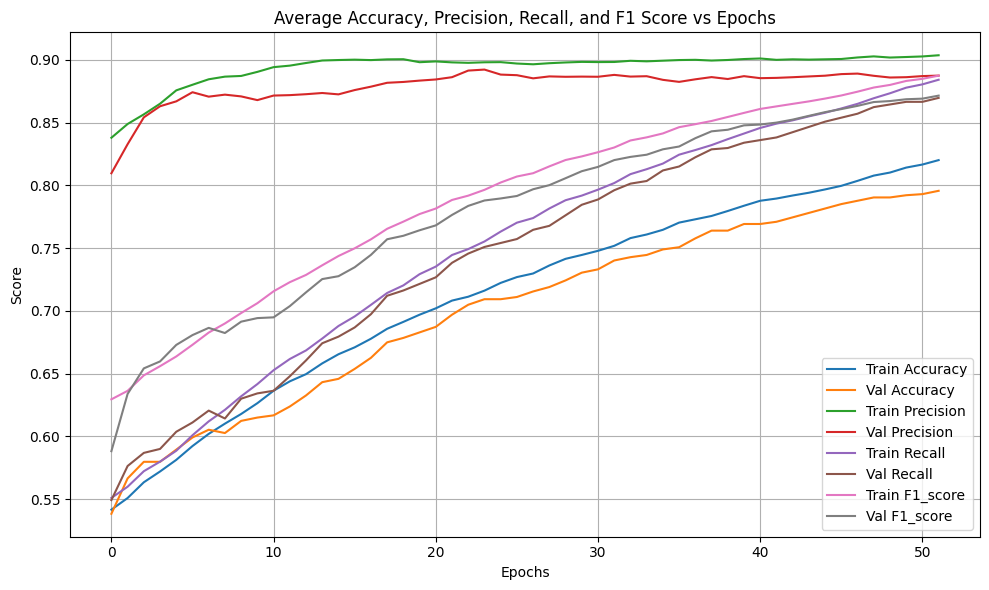

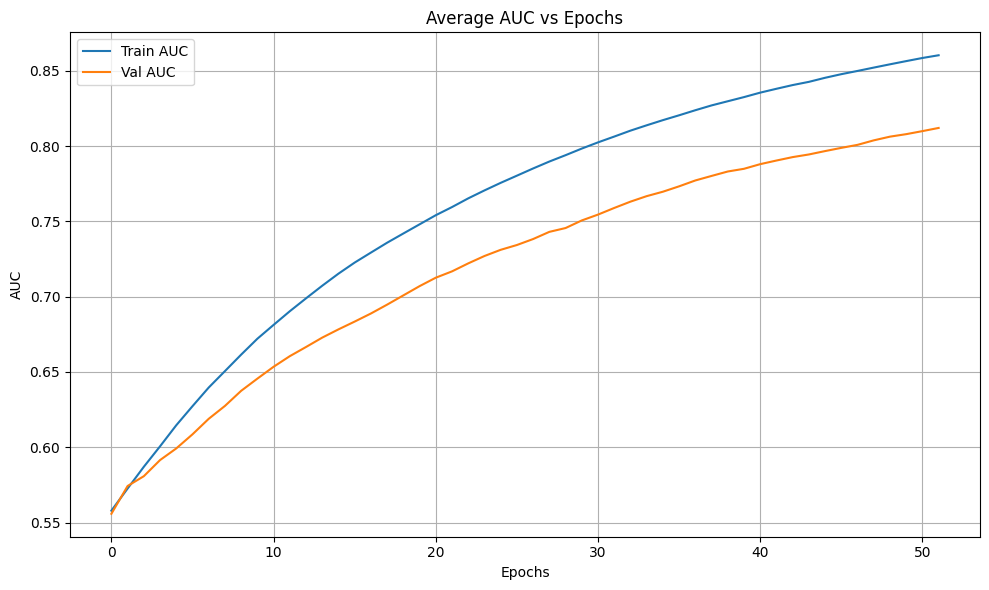


=== Average Metrics at Final Epoch (Mean ± Std) ===
classification_accuracy: 0.8200 ± 0.0752
classification_auc: 0.8603 ± 0.0617
classification_f1_score: 0.8873 ± 0.0581
classification_loss: 0.4301 ± 0.1101
classification_precision: 0.9036 ± 0.0314
classification_recall: 0.8841 ± 0.1199
loss: 0.5019 ± 0.1045
reconstruction_loss: 0.7105 ± 0.1248
reconstruction_mae: 0.6412 ± 0.0578
reconstruction_mse: 0.7087 ± 0.1252
val_classification_accuracy: 0.7956 ± 0.0915
val_classification_auc: 0.8120 ± 0.0553
val_classification_f1_score: 0.8714 ± 0.0716
val_classification_loss: 0.4629 ± 0.1037
val_classification_precision: 0.8873 ± 0.0271
val_classification_recall: 0.8696 ± 0.1332
val_loss: 0.5302 ± 0.1093
val_reconstruction_loss: 0.7143 ± 0.1238
val_reconstruction_mae: 0.6425 ± 0.0550
val_reconstruction_mse: 0.7167 ± 0.1204
Training completed!
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


In [52]:
print("Starting training...")
main_model, history, scaler, intermediate_model, X_train = train_model()
print("Training completed!")
intermediate_outputs = intermediate_model.predict(X_train)

In [53]:
import tensorflow as tf

def correlation(tensor1, tensor2):
  """
  Calculates the Pearson correlation coefficient between two TensorFlow tensors.

  Args:
    tensor1: A TensorFlow tensor representing the first vector.
    tensor2: A TensorFlow tensor representing the second vector.

  Returns:
    A TensorFlow tensor representing the correlation coefficient.
  """
  # Ensure tensors have the same shape
  tensor1 = tf.reshape(tensor1, [-1])
  tensor2 = tf.reshape(tensor2, [-1])

  # Calculate mean-centered product and standard deviations
  cov = tf.reduce_mean((tensor1 - tf.reduce_mean(tensor1)) * (tensor2 - tf.reduce_mean(tensor2)))
  std1 = tf.sqrt(tf.reduce_mean(tensor1**2))
  std2 = tf.sqrt(tf.reduce_mean(tensor2**2))

  # Prevent division by zero
  tolerance = 1e-8
  correlation = tf.where(tf.abs(std1 * std2) > tolerance, cov / (std1 * std2), tf.constant(0.0))

  return correlation

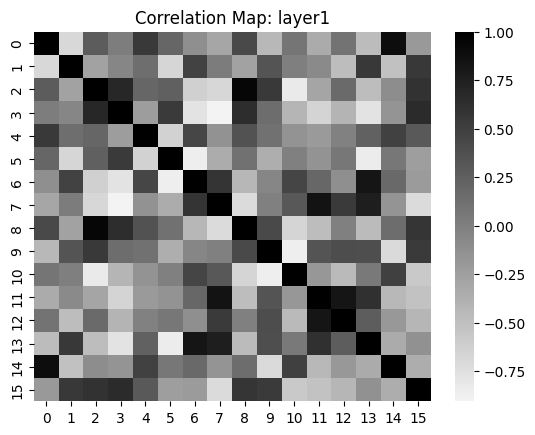

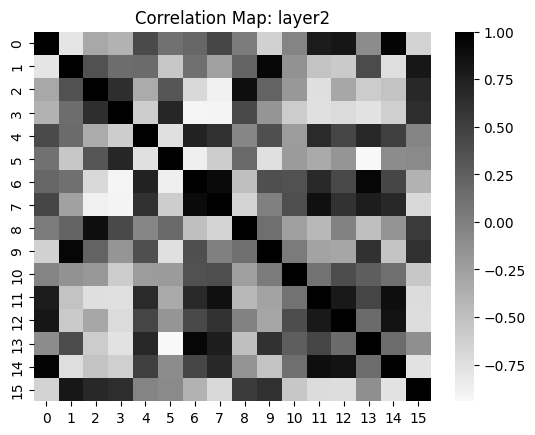

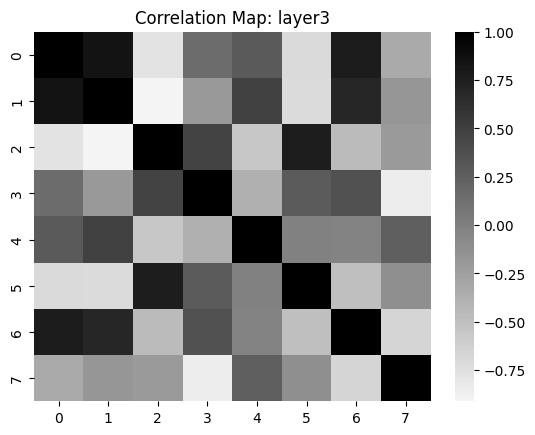

Skipping layer4 due to insufficient channels: shape = (12, 1)
Skipping layer5 due to insufficient channels: shape = (12, 1)


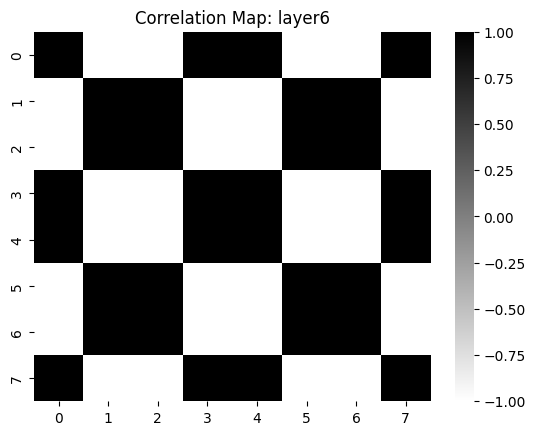

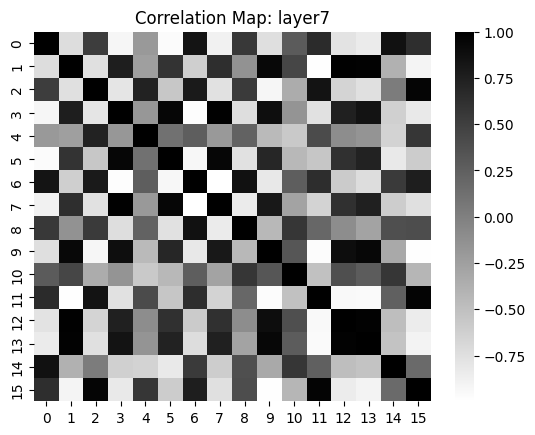

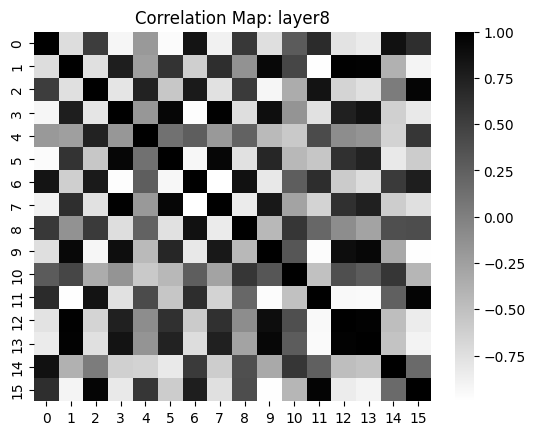

Skipping layer9 due to insufficient channels: shape = (24, 1)


In [54]:
patient_idx = 100
import seaborn as sns
import matplotlib.pyplot as plt

# Function to plot correlation matrix
def plot_correlation_map(data, layer_name):
    corr = np.corrcoef(data, rowvar=False)
    sns.heatmap(corr, annot=False, cmap='gist_yarg', center=0)
    plt.title(f'Correlation Map: {layer_name}')
    plt.show()

# Plot correlation maps for each layer
layer_names = ['layer1', 'layer2', 'layer3', 'layer4', 'layer5', 'layer6', 'layer7', 'layer8', 'layer9']
for layer_output, layer_name in zip(intermediate_outputs, layer_names):
    # Skip layers that are too small
    if layer_output[patient_idx].ndim < 2 or layer_output[patient_idx].shape[1] < 2:
        print(f"Skipping {layer_name} due to insufficient channels: shape = {layer_output[patient_idx].shape}")
        continue

    temp_layer_output = layer_output[patient_idx]
    num_channels = temp_layer_output.shape[1]
    corr_matrix = np.zeros((num_channels, num_channels))

    for i in range(num_channels):
        for j in range(num_channels):
            corr_matrix[i, j] = correlation(temp_layer_output[:, i], temp_layer_output[:, j])

    try:
        plot_correlation_map(corr_matrix, layer_name)
    except Exception as e:
        print(f"Error in {layer_name}: {e}")
        print(corr_matrix.shape)
